In [1]:
import pandas as pd
import seaborn as sns
from glob import glob
sns.set_theme(style="ticks", font="Linux Biolinum O", font_scale=1.2)

frames = [pd.read_csv(data) for data in glob('../data/operation-*.txt')]
for frame in frames:
    if 'num_participant' not in frame:
        frame['num_participant'] = 10000
data = pd.concat(frames, ignore_index=True)
data = data[data['comment'].isna()]

data = data[data['num_concurrent'] == 8]
data = data[(data['inner_k'] == 32) & (data['inner_n'] == 80) & (data['outer_k'] == 8) & (data['outer_n'] == 10)]

def protocol_operation(row):
    return f'{row["protocol"].capitalize()} - {row["operation"]}'

data["Protocol - Operation"] = data.apply(protocol_operation, axis=1)
data

,comment,peer,operation,latency,protocol,inner_k,inner_n,outer_k,outer_n,num_concurrent,num_participant,key,Protocol - Operation
822,NaN,http://ec2-52-53-150-0.us-west-1.compute.amazo...,put,10.848198,kademlia,32.0,80.0,8.0,10.0,8.0,3000.0,NaN,Kademlia - put
824,NaN,http://ec2-54-233-189-65.sa-east-1.compute.ama...,put,12.369477,kademlia,32.0,80.0,8.0,10.0,8.0,3000.0,NaN,Kademlia - put
825,NaN,http://ec2-18-231-178-252.sa-east-1.compute.am...,put,12.161664,kademlia,32.0,80.0,8.0,10.0,8.0,3000.0,NaN,Kademlia - put
826,NaN,http://ec2-13-245-182-169.af-south-1.compute.a...,put,12.402375,kademlia,32.0,80.0,8.0,10.0,8.0,3000.0,NaN,Kademlia - put
830,NaN,http://ec2-3-75-176-24.eu-central-1.compute.am...,put,14.264183,kademlia,32.0,80.0,8.0,10.0,8.0,3000.0,NaN,Kademlia - put
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21398,NaN,NaN,repair,3.227211,entropy,32.0,80.0,8.0,10.0,8.0,2000.0,f8888041e22bc552002cf2cc8551fe469b9377d6c54c41...,Entropy - repair
21399,NaN,NaN,repair,2.987068,entropy,32.0,80.0,8.0,10.0,8.0,2000.0,b0fa5be7cabb78984f394f0c6c620740bad2583fa17067...,Entropy - repair
21400,NaN,NaN,repair,3.933765,entropy,32.0,80.0,8.0,10.0,8.0,2000.0,e46a84b4d9a39599deb4ab603b8faa7cd9d147bf2fd68f...,Entropy - repair
21401,NaN,NaN,repair,3.960692,entropy,32.0,80.0,8.0,10.0,8.0,2000.0,b621ee8674c272926b8d96a0f437a869102aaecde311fa...,Entropy - repair


/tmp/ipykernel_924643/2823062868.py:7: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.relplot(data=data,


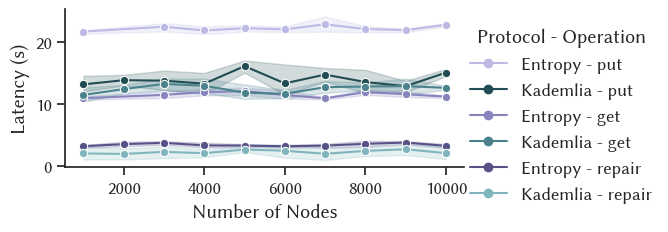

In [2]:
hue_order = ["entropy - put", "kademlia - put", "entropy - get", "kademlia - get", "entropy - repair", "kademlia - repair"]
hue_order = [f"{p} - {o}" for o in ("put", "get", "repair") for p in ("Entropy", "Kademlia")]
entropy_palette = sns.cubehelix_palette(rot=0., light=0.75, n_colors=4)
kademlia_palette = sns.cubehelix_palette(start=2.5, rot=0., dark=0.25, n_colors=4)
palette = [c for p in zip(entropy_palette, reversed(kademlia_palette)) for c in p]

sns.relplot(data=data,
    kind="line",
    x="num_participant", y="latency", hue="Protocol - Operation",
    markers=['o'] * 6, dashes=False, style='Protocol - Operation',
    hue_order=hue_order, palette=palette,
    height=2.56, aspect=2.) \
.set_xlabels("Number of Nodes") \
.set_ylabels("Latency (s)") \
.savefig("../../graphs/scale.pdf")